# Ejercicios: 

## Clasificación datos bancarios

- Importa los datos provinientes de riesgo de crédito
- Analiza las variables de que dispones: sus formatos, dominio y valores que toman, las relaciones entre las variables explicativas entre sí, y con la dependiente. **Muy importante este punto, te ahorrará tiempo futuro y te ayudará a obtener un buen modelo**
- Divide en entrenamiento y test
- Diseña la ingeniería de variables: Optimiza las variables discretas en categorías más significativas (y haz dummy), y categoriza las variables continuas usando la métrica WOE
- Estandariza las variables continuas si lo consideras necesario
- Entrena varios modelos con características e hipermparámetros diferentes y elige uno como el mejor, el que mejor clasifica tus clientes

## Predicción precios casas

 - Importa el fichero house_pricing.csv
 - Analiza las variables de que dispones: sus formatos, dominio y valores que toman, las relaciones entre las variables explicativas entre sí, y con la dependiente. **Muy importante este punto, te ahorrará tiempo futuro y te ayudará a obtener un buen modelo** 
 - Divide en entrenamiento y test
 - Diseña la ingeniería de variables: Optimiza las variables discretas en categorías más significativas (y haz dummy)
 - Estandariza las variables continuas si lo consideras necesario
 - Entrena varios modelos con características e hipermparámetros diferentes y elige uno como el mejor, el que mejor clasifica tus clientes
 
 
   #### bank client data
   1 - age (numeric)
   
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   
   5 - default: has credit in default? (binary: "yes","no")
   
   6 - balance: average yearly balance, in euros (numeric) 
   
   7 - housing: has housing loan? (binary: "yes","no")
   
   8 - loan: has personal loan? (binary: "yes","no") 
   
   #### related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
  
  10 - day: last contact day of the month (numeric)
  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  
  12 - duration: last contact duration, in seconds (numeric)
   
   ##### other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  #### Output variable (desired target):
  
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")

--------------------------------------------------

  #### house pricing Feature Description:

 - id: Unique identifier for each property.
 - date: Date of sale.
 - price: Sale price of the house.
 - bedrooms: Number of bedrooms.
 - bathrooms: Number of bathrooms (including partials as fractions).
 - sqft_living: Living space area in square feet.
 - sqft_lot: Lot size in square feet.
 - floors: Number of floors.
 - waterfront: Whether the property has a waterfront view.
 - view: Quality of the view rating.
 - condition: Overall condition of the house.
 - grade: Grade of construction and design (scale of 1–13).
 - sqft_above: Square footage of the property above ground.
 - sqft_basement: Basement area in square feet.
 - yr_built: Year the property was built.
 - yr_renovated: Year of last renovation.
 - zipcode: ZIP code of the property.
 - lat and long: Latitude and longitude coordinates.
 - sqft_living15: Average living space of 15 nearest properties.
 - sqft_lot15: Average lot size of 15 nearest properties.

In [126]:
#!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 



In [4]:
X

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [6]:
y

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
dtypes: int64(7), object(9)
memory usage: 5.5+ MB


In [10]:
#pip install --upgrade scikit-learn

In [12]:
#pip install scikit-learn==1.2.2

In [14]:
import sklearn
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.6.1


In [16]:
#pip install --upgrade scikit-learn imbalanced-learn

In [18]:
import sklearn, imblearn
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
from imblearn.under_sampling import RandomUnderSampler

scikit-learn: 1.6.1
imbalanced-learn: 0.13.0


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,RepeatedStratifiedKFold,cross_val_score, GridSearchCV
# !pip install scikit-learn==0.20.0
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, roc_curve, roc_auc_score, r2_score
# from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
!pip install mlxtend
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from statsmodels.stats.outliers_influence import variance_inflation_factor

#!pip install builder
#!pip install optbinning
from optbinning import BinningProcess, OptimalBinning # Para cáclulos WOE e IV

from tabulate import tabulate

import warnings
warnings.filterwarnings("ignore")

In [22]:
from scipy.stats import chi2_contingency
from itertools import combinations

def cramers_v_matrix(df):
    # Seleccionar solo columnas categóricas
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    result = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
    
    def cramers_v(x, y):
        confusion_matrix = pd.crosstab(x, y)
        if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
            return np.nan  # Evitar divisiones por 0
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        return np.sqrt(phi2 / min(k - 1, r - 1))
    
    for var1, var2 in combinations(cat_cols, 2):
        v = cramers_v(df[var1], df[var2])
        result.loc[var1, var2] = v
        result.loc[var2, var1] = v
    
    np.fill_diagonal(result.values, 1.0)  # La diagonal es 1 (correlación perfecta consigo misma)
    return result

In [24]:
cramers_v_matrix(X)

,job,marital,education,default,housing,loan,contact,month,poutcome
job,1.000000,0.206185,0.554547,0.035965,0.272626,0.101683,0.144632,0.114331,0.136184
marital,0.206185,1.000000,0.123701,0.019230,0.020685,0.051937,0.063277,0.072317,0.043192
education,0.554547,0.123701,1.000000,0.016169,0.111886,0.063541,0.121849,0.132720,0.072293
default,0.035965,0.019230,0.016169,1.000000,0.005858,0.077008,0.017087,0.058675,0.032120
housing,0.272626,0.020685,0.111886,0.005858,1.000000,0.041262,0.054945,0.504213,0.307550
loan,0.101683,0.051937,0.063541,0.077008,0.041262,1.000000,0.017070,0.182827,0.113903
contact,0.144632,0.063277,0.121849,0.017087,0.054945,0.017070,1.000000,0.119501,0.040797
month,0.114331,0.072317,0.132720,0.058675,0.504213,0.182827,0.119501,1.000000,0.228118
poutcome,0.136184,0.043192,0.072293,0.032120,0.307550,0.113903,0.040797,0.228118,1.000000


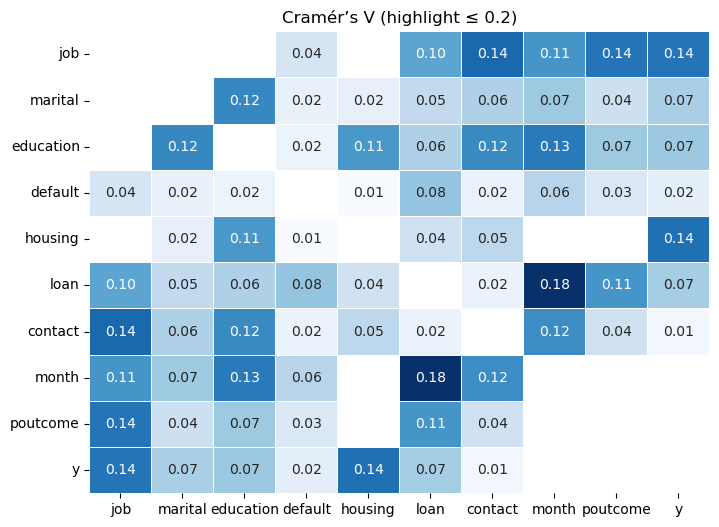

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

cramers = cramers_v_matrix(X)

mask = cramers > 0.2  # hide everything above 0.2
plt.figure(figsize=(8, 6))
sns.heatmap(
    cramers,
    mask=mask,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar=False,
    cmap="Blues"
)
plt.title("Cramér’s V (highlight ≤ 0.2)")
plt.show()

#### De variables categóricas escojo: default, loan, contact y marital para mi primera aproximaxión. Teniendo en cuenta que contact tiene unos 13.000 nulos lo elimino

In [29]:
X.contact.value_counts()

contact
cellular     29285
telephone     2906
Name: count, dtype: int64

In [31]:
X.loan.value_counts()

loan
no     37967
yes     7244
Name: count, dtype: int64

In [33]:
X.default.value_counts()

default
no     44396
yes      815
Name: count, dtype: int64

In [35]:
X.marital.value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [37]:
y.value_counts()

y  
no     39922
yes     5289
Name: count, dtype: int64

In [39]:
X_copy=X.copy()

In [41]:
X_copy

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [43]:
X_VIF = X[['age', 'balance', 'day_of_week',
       'duration', 'campaign', 'pdays', 'previous']]
vif_data = pd.DataFrame()
vif_data["variable"] = X_VIF.columns
vif_data["VIF"] = [variance_inflation_factor(X_VIF.values, i) for i in range(X_VIF.shape[1])]

vif_data

,variable,VIF
0,age,5.004058
1,balance,1.212908
2,day_of_week,3.984268
3,duration,1.901309
4,campaign,1.824694
5,pdays,1.454202
6,previous,1.341641


### En cuanto a vartiables numéticas me quedaré con todas menos age

In [48]:
X['y'] = y

In [50]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [52]:
X_clean_contact = X.drop(columns=["poutcome"])


In [54]:
X_clean_contact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  y            45211 non-null  object
dtypes: int64(7), object(9)
memory usage: 5.5+ MB


In [56]:
X_clean_contact=X_clean_contact.dropna(subset=['contact'])
X_clean_contact.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32191 entries, 12657 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          32191 non-null  int64 
 1   job          32014 non-null  object
 2   marital      32191 non-null  object
 3   education    31011 non-null  object
 4   default      32191 non-null  object
 5   balance      32191 non-null  int64 
 6   housing      32191 non-null  object
 7   loan         32191 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  32191 non-null  int64 
 10  month        32191 non-null  object
 11  duration     32191 non-null  int64 
 12  campaign     32191 non-null  int64 
 13  pdays        32191 non-null  int64 
 14  previous     32191 non-null  int64 
 15  y            32191 non-null  object
dtypes: int64(7), object(9)
memory usage: 4.2+ MB


In [58]:
default={'no': 0, 'yes': 1}  
loan={'no': 0, 'yes': 1}  
contact={'cellular': 0, 'telephone': 1}  
marital={'married': 0, 'single': 1, 'divorced': 2} 

def encode(dic, x):   
    return dic[x]    

X_clean_contact['default2']=X_clean_contact['default'].apply(lambda x: default[x])
X_clean_contact['loan2']=X_clean_contact['loan'].apply(lambda x: loan[x])
X_clean_contact['contact2']=X_clean_contact['contact'].apply(lambda x: contact[x])
X_clean_contact['marital2']=X_clean_contact['marital'].apply(lambda x: marital[x])

X_clean_contact.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,y,default2,loan2,contact2,marital2
12657,27,management,single,secondary,no,35,no,no,cellular,4,jul,255,1,-1,0,no,0,0,0,1
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,jul,297,1,-1,0,no,0,0,0,0
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,jul,668,2,-1,0,no,0,1,0,0
12660,31,technician,single,secondary,no,19,no,no,telephone,4,jul,65,2,-1,0,no,0,0,1,1
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,jul,436,4,-1,0,no,0,1,0,1


In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_clean_contact[['default2','loan2','contact2','marital2','balance','day_of_week','duration','campaign','pdays','previous']], 
                                                    X_clean_contact['y'], train_size = 0.8, random_state = 0)

In [62]:
print(X_train.shape)
print(X_test.shape)

(25752, 10)
(6439, 10)


In [64]:
X_train

,default2,loan2,contact2,marital2,balance,day_of_week,duration,campaign,pdays,previous
21028,0,0,0,0,867,14,159,2,-1,0
13397,0,1,1,0,0,9,42,1,-1,0
19882,0,0,0,0,134,8,104,4,-1,0
12702,0,0,0,0,1618,7,134,2,-1,0
20495,0,0,0,2,277,12,101,3,-1,0
...,...,...,...,...,...,...,...,...,...,...
25883,0,0,0,2,57,19,134,1,-1,0
32413,0,0,0,1,617,16,282,2,259,4
22532,0,0,0,1,0,22,132,4,-1,0
23486,0,0,0,1,1070,28,91,15,-1,0


In [66]:
classifiers = {
    'LogisticRegression': (LogisticRegression(), {'penalty': ['l1','l2'], 'solver':['saga','liblinear']}),
    'RandomForestClassifier': (RandomForestClassifier(), {'max_depth': [None, 10, 20],'criterion':['gini','entropy']})
}

In [68]:
cross_val = RepeatedStratifiedKFold(n_splits=5, random_state=1)
results = {}
for clf_name, (clf, params) in classifiers.items():
    grid_search = GridSearchCV(clf, params, cv=cross_val, scoring = 'accuracy')
    grid_search.fit(X_train, y_train)
    results[clf_name] = {
        'Best Parameters': grid_search.best_params_,
        'Best Score': grid_search.best_score_
    }

In [69]:
for clf_name, result in results.items():
    print(f'Classifier: {clf_name}')
    print(f'Best Parameters: {result["Best Parameters"]}')
    print(f'Best Score: {result["Best Score"]}\n')

Classifier: LogisticRegression
Best Parameters: {'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.8618204235957577

Classifier: RandomForestClassifier
Best Parameters: {'criterion': 'gini', 'max_depth': 10}
Best Score: 0.8721730398282547



In [72]:
rf_clf = RandomForestClassifier(n_estimators = 3, criterion ='gini') #  criterion ='entropy' 
rf_clf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=3)

In [74]:
y_predict = rf_clf.predict(X_test)
y_predict

array(['yes', 'no', 'yes', ..., 'no', 'no', 'no'], dtype=object)

In [76]:
y_test

35553    yes
30277     no
41960     no
25917     no
37797     no
        ... 
35440     no
23593     no
35428     no
26860     no
16638     no
Name: y, Length: 6439, dtype: object

In [78]:
df_y_test = pd.DataFrame(y_test)
df_y_test['pred'] = y_predict
df_y_test

,y,pred
35553,yes,yes
30277,no,no
41960,no,yes
25917,no,no
37797,no,no
...,...,...
35440,no,no
23593,no,no
35428,no,no
26860,no,no


In [80]:
# compute scores
train_score = rf_clf.score(X_train, y_train)
test_score  = rf_clf.score(X_test,  y_test)

# round via built-in
print("Train set score (Accuracy) =", round(train_score, 4))
print("Test set score  (Accuracy) =", round(test_score,  4))

Train set score (Accuracy) = 0.9685
Test set score  (Accuracy) = 0.84


In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,recall_score, f1_score


# 1) Compute and print your scores
train_score = rf_clf.score(X_train, y_train)
test_score  = rf_clf.score(X_test,  y_test)
print("Train set score (Accuracy) =", round(train_score, 4))
print("Test set score  (Accuracy) =", round(test_score,  4))

# 2) Compute the confusion matrix
y_pred = rf_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 3a) Print the raw matrix
print("\nConfusion matrix (counts):")
print(cm)

# 3b) Tabulate if you like
from tabulate import tabulate
print(
    tabulate(
        cm,
        headers=["pred No", "pred Yes"],
        showindex=["real No", "real Yes"],
        tablefmt="fancy_grid"
    )
)

# 4) Display as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf_clf.classes_)

# 5) Compute and print recall & F1 for the positive (“Yes”) class
recall = recall_score(y_test, y_pred, pos_label=rf_clf.classes_[1])
f1     = f1_score  (y_test, y_pred, pos_label=rf_clf.classes_[1])
print(f"\nRecall (Yes): {recall:.4f}")
print(f"F1-score (Yes): {f1:.4f}")

Train set score (Accuracy) = 0.9685
Test set score  (Accuracy) = 0.84

Confusion matrix (counts):
[[5053  410]
 [ 620  356]]
╒══════════╤═══════════╤════════════╕
│          │   pred No │   pred Yes │
╞══════════╪═══════════╪════════════╡
│ real No  │      5053 │        410 │
├──────────┼───────────┼────────────┤
│ real Yes │       620 │        356 │
╘══════════╧═══════════╧════════════╛

Recall (Yes): 0.3648
F1-score (Yes): 0.4087


### Procedo a analizar lo nulos de potucome y contact

In [85]:
df_poutcome_nan = X[X["poutcome"].isna()]
df_poutcome_nan

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45203,23,student,single,tertiary,no,113,no,no,cellular,17,nov,266,1,-1,0,NaN,yes
45205,25,technician,single,secondary,no,505,no,yes,cellular,17,nov,386,2,-1,0,NaN,yes
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes


In [89]:
df_poutcome_nan.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,36959.000000,36959.000000,36959.000000,36959.000000,36959.000000,36959.000000,36959.000000
mean,40.932114,1318.722043,16.145621,257.738332,2.921886,-0.962039,0.000460
std,10.430504,3039.386767,8.372530,262.266179,3.325601,3.778887,0.047388
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,55.000000,9.000000,101.000000,1.000000,-1.000000,0.000000
50%,39.000000,414.000000,17.000000,177.000000,2.000000,-1.000000,0.000000
75%,49.000000,1358.000000,22.000000,318.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,528.000000,7.000000


In [103]:
df_poutcome_nan.campaign.value_counts()

campaign
1     13531
2     10229
3      4610
4      3098
5      1508
6      1128
7       638
8       486
9       303
10      256
11      189
12      148
13      131
14       92
15       83
16       78
17       69
18       51
19       44
20       43
21       35
22       23
25       22
23       22
24       20
29       16
28       16
26       13
31       12
27       10
32        9
30        8
33        6
34        5
36        4
35        4
43        3
38        3
37        2
50        2
41        2
46        1
58        1
55        1
63        1
51        1
39        1
44        1
Name: count, dtype: int64

In [93]:
df_poutcome_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36959 entries, 0 to 45209
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          36959 non-null  int64 
 1   job          36704 non-null  object
 2   marital      36959 non-null  object
 3   education    35425 non-null  object
 4   default      36959 non-null  object
 5   balance      36959 non-null  int64 
 6   housing      36959 non-null  object
 7   loan         36959 non-null  object
 8   contact      24009 non-null  object
 9   day_of_week  36959 non-null  int64 
 10  month        36959 non-null  object
 11  duration     36959 non-null  int64 
 12  campaign     36959 non-null  int64 
 13  pdays        36959 non-null  int64 
 14  previous     36959 non-null  int64 
 15  poutcome     0 non-null      object
 16  y            36959 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.1+ MB


In [87]:
df_contact_nan = X[X["contact"].isna()]
df_contact_nan

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45061,30,self-employed,single,secondary,no,1031,no,no,NaN,20,oct,7,1,-1,0,NaN,no
45062,58,retired,married,primary,no,742,no,no,NaN,20,oct,5,1,-1,0,NaN,no
45122,40,entrepreneur,single,tertiary,no,262,yes,yes,NaN,26,oct,17,1,-1,0,NaN,no
45135,53,blue-collar,married,primary,no,1294,no,no,NaN,28,oct,71,1,-1,0,NaN,no


In [91]:
df_contact_nan.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,13020.000000,13020.000000,13020.000000,13020.000000,13020.000000,13020.000000,13020.000000
mean,40.600077,1183.550384,15.360138,252.340476,2.787481,1.299386,0.021966
std,9.439221,2638.647690,8.454077,258.405545,3.371954,36.451647,0.502526
min,20.000000,-3372.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,50.000000,8.000000,101.000000,1.000000,-1.000000,0.000000
50%,39.000000,389.000000,15.000000,178.000000,2.000000,-1.000000,0.000000
75%,48.000000,1255.250000,21.000000,311.000000,3.000000,-1.000000,0.000000
max,61.000000,58544.000000,31.000000,3881.000000,63.000000,850.000000,41.000000


In [95]:
df_contact_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13020 entries, 0 to 45136
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          13020 non-null  int64 
 1   job          12909 non-null  object
 2   marital      13020 non-null  object
 3   education    12343 non-null  object
 4   default      13020 non-null  object
 5   balance      13020 non-null  int64 
 6   housing      13020 non-null  object
 7   loan         13020 non-null  object
 8   contact      0 non-null      object
 9   day_of_week  13020 non-null  int64 
 10  month        13020 non-null  object
 11  duration     13020 non-null  int64 
 12  campaign     13020 non-null  int64 
 13  pdays        13020 non-null  int64 
 14  previous     13020 non-null  int64 
 15  poutcome     70 non-null     object
 16  y            13020 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.8+ MB


In [105]:
df_contact_notna = X[X["contact"].notna()]
df_contact_notna

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
12657,27,management,single,secondary,no,35,no,no,cellular,4,jul,255,1,-1,0,NaN,no
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,jul,297,1,-1,0,NaN,no
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,jul,668,2,-1,0,NaN,no
12660,31,technician,single,secondary,no,19,no,no,telephone,4,jul,65,2,-1,0,NaN,no
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,jul,436,4,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no


In [107]:
#Procedo a transformar mi variable mi variables objetivo a binaria
y={'no': 0, 'yes': 1}  

def encode(dic, x):   
    return dic[x]    

X_clean_contact['y2']=X_clean_contact['y'].apply(lambda x: default[x])

X_clean_contact.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,...,duration,campaign,pdays,previous,y,default2,loan2,contact2,marital2,y2
12657,27,management,single,secondary,no,35,no,no,cellular,4,...,255,1,-1,0,no,0,0,0,1,0
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,...,297,1,-1,0,no,0,0,0,0,0
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,...,668,2,-1,0,no,0,1,0,0,0
12660,31,technician,single,secondary,no,19,no,no,telephone,4,...,65,2,-1,0,no,0,0,1,1,0
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,...,436,4,-1,0,no,0,1,0,1,0


In [254]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_clean_contact[['default2','loan2','contact2','marital2','balance','day_of_week','duration','campaign','pdays','previous']], 
                                                    X_clean_contact['y2'], train_size = 0.8, random_state = 0)

In [256]:
print(X_train_1.shape)

(25752, 10)


In [258]:
print(y_train_1.shape)

(25752,)


In [261]:
from imblearn.over_sampling import RandomOverSampler

In [263]:
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros= ros.fit_resample(X_train_1, y_train_1)

In [265]:
 y_train_ros.value_counts()

y2
0    21969
1    21969
Name: count, dtype: int64

In [267]:
rf_clf = RandomForestClassifier(n_estimators = 3, criterion ='gini') #  criterion ='entropy' 
rf_clf.fit(X_train_ros,y_train_ros)

RandomForestClassifier(n_estimators=3)

In [269]:
y_predict = rf_clf.predict(X_test_1)
y_predict

array([1, 0, 1, ..., 1, 0, 0])

In [271]:
y_test_1

35553    1
30277    0
41960    0
25917    0
37797    0
        ..
35440    0
23593    0
35428    0
26860    0
16638    0
Name: y2, Length: 6439, dtype: int64

In [273]:
df_y_test = pd.DataFrame(y_test_1)
df_y_test['pred'] = y_predict
df_y_test

,y2,pred
35553,1,1
30277,0,0
41960,0,1
25917,0,0
37797,0,0
...,...,...
35440,0,0
23593,0,0
35428,0,1
26860,0,0


In [275]:
# compute scores
train_score = rf_clf.score(X_train_1, y_train_1)
test_score  = rf_clf.score(X_test_1,  y_test_1)

# round via built-in
print("Train set score (Accuracy) =", round(train_score, 4))
print("Test set score  (Accuracy) =", round(test_score,  4))

Train set score (Accuracy) = 0.9829
Test set score  (Accuracy) = 0.8332


In [277]:
# 1) Compute and print your scores
train_score = rf_clf.score(X_train_1, y_train_1)
test_score  = rf_clf.score(X_test_1,  y_test_1)
print("Train set score (Accuracy) =", round(train_score, 4))
print("Test set score  (Accuracy) =", round(test_score,  4))

# 2) Compute the confusion matrix
y_pred = rf_clf.predict(X_test_1)
cm = confusion_matrix(y_test_1, y_pred)

# 3a) Print the raw matrix
print("\nConfusion matrix (counts):")
print(cm)

# 3b) Tabulate if you like
from tabulate import tabulate
print(
    tabulate(
        cm,
        headers=["pred No", "pred Yes"],
        showindex=["real No", "real Yes"],
        tablefmt="fancy_grid"
    )
)

# 4) Display as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf_clf.classes_)

# 5) Compute and print recall & F1 for the positive (“Yes”) class
recall = recall_score(y_test_1, y_pred, pos_label=rf_clf.classes_[1])
f1     = f1_score  (y_test_1, y_pred, pos_label=rf_clf.classes_[1])
print(f"\nRecall (Yes): {recall:.4f}")
print(f"F1-score (Yes): {f1:.4f}")

Train set score (Accuracy) = 0.9829
Test set score  (Accuracy) = 0.8332

Confusion matrix (counts):
[[4902  561]
 [ 513  463]]
╒══════════╤═══════════╤════════════╕
│          │   pred No │   pred Yes │
╞══════════╪═══════════╪════════════╡
│ real No  │      4902 │        561 │
├──────────┼───────────┼────────────┤
│ real Yes │       513 │        463 │
╘══════════╧═══════════╧════════════╛

Recall (Yes): 0.4744
F1-score (Yes): 0.4630


# Ahora voy a proceder a utilixar todas las variables para ver cómo cmabian los resultados

In [157]:
X_clean_contact

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,...,duration,campaign,pdays,previous,y,default2,loan2,contact2,marital2,y2
12657,27,management,single,secondary,no,35,no,no,cellular,4,...,255,1,-1,0,no,0,0,0,1,0
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,...,297,1,-1,0,no,0,0,0,0,0
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,...,668,2,-1,0,no,0,1,0,0,0
12660,31,technician,single,secondary,no,19,no,no,telephone,4,...,65,2,-1,0,no,0,0,1,1,0
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,...,436,4,-1,0,no,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,...,977,3,-1,0,yes,0,0,0,0,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,...,456,2,-1,0,yes,0,0,0,2,1
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,...,1127,5,184,3,yes,0,0,0,0,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,...,508,4,-1,0,no,0,0,1,0,0


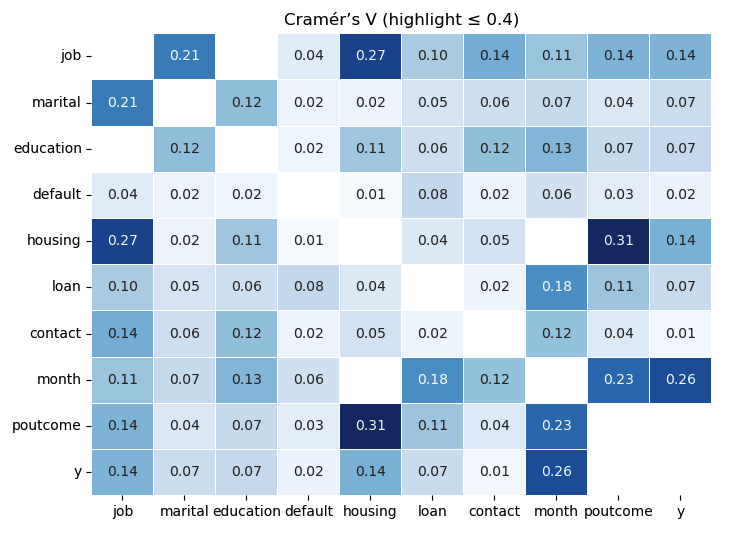

In [159]:
X_clean_contact.education.value_counts()

education
secondary    16053
tertiary     10668
primary       4290
Name: count, dtype: int64

In [179]:
X_clean_contact.month.value_counts()

month
jul    6619
aug    6196
may    5791
nov    3919
apr    2926
feb    2636
jan    1394
jun     809
oct     688
sep     532
mar     470
dec     211
Name: count, dtype: int64

In [181]:
X_clean_contact.housing.value_counts()

housing
no     16418
yes    15773
Name: count, dtype: int64

In [209]:
X_clean_contact_2 = X_clean_contact.dropna(subset=["education"])

education={"secondary": 0, 'tertiary': 1, 'primary': 2}  
housing={'no': 0, 'yes': 1}  


def encode(dic, x):   
    return dic[x]    

X_clean_contact_2['education2']=X_clean_contact_2['education'].apply(lambda x: education[x])
X_clean_contact_2['housing2']=X_clean_contact_2['housing'].apply(lambda x:housing[x])


X_clean_contact_2.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,...,pdays,previous,y,default2,loan2,contact2,marital2,y2,education2,housing2
12657,27,management,single,secondary,no,35,no,no,cellular,4,...,-1,0,no,0,0,0,1,0,0,0
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,...,-1,0,no,0,0,0,0,0,2,0
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,...,-1,0,no,0,1,0,0,0,0,0
12660,31,technician,single,secondary,no,19,no,no,telephone,4,...,-1,0,no,0,0,1,1,0,0,0
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,...,-1,0,no,0,1,0,1,0,0,1


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,...,campaign,pdays,previous,y,default2,loan2,contact2,marital2,y2,education2
12657,27,management,single,secondary,no,35,no,no,cellular,4,...,1,-1,0,no,0,0,0,1,0,0
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,...,1,-1,0,no,0,0,0,0,0,2
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,...,2,-1,0,no,0,1,0,0,0,0
12660,31,technician,single,secondary,no,19,no,no,telephone,4,...,2,-1,0,no,0,0,1,1,0,0
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,...,4,-1,0,no,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,...,3,-1,0,yes,0,0,0,0,1,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,...,2,-1,0,yes,0,0,0,2,1,2
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,...,5,184,3,yes,0,0,0,0,1,0
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,...,4,-1,0,no,0,0,1,0,0,0


In [297]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_clean_contact_2[['default2','loan2','contact2','marital2','education2','housing2','balance','day_of_week','duration','campaign','pdays','previous','age']], 
                                                    X_clean_contact_2['y2'], train_size = 0.8, random_state = 0)

In [299]:
ros = RandomOverSampler(random_state=42)
X_train_ros_2, y_train_ros_2= ros.fit_resample(X_train_2, y_train_2)

In [301]:
y_train_ros_2.value_counts()

y2
0    21213
1    21213
Name: count, dtype: int64

In [336]:
rf_clf = RandomForestClassifier(n_estimators = 50, criterion ='gini', class_weight='balanced') #  criterion ='entropy' 
rf_clf.fit(X_train_ros_2,y_train_ros_2)

RandomForestClassifier(class_weight='balanced', n_estimators=50)

In [338]:
y_predict_2 = rf_clf.predict(X_test_2)
y_predict_2

array([0, 0, 0, ..., 0, 0, 0])

In [340]:
df_y_test_2 = pd.DataFrame(y_test_2)
df_y_test_2['pred'] = y_predict_2
df_y_test_2

,y2,pred
36013,0,0
29457,0,0
37382,0,0
24793,0,0
19853,0,0
...,...,...
44349,1,1
25884,0,0
38249,0,0
17664,0,0


In [342]:
# compute scores
train_score_2 = rf_clf.score(X_train_2, y_train_2)
test_score_2  = rf_clf.score(X_test_2,  y_test_2)

# print with rounding
print("Train set score (Accuracy) =", round(train_score_2, 4))
print("Test set score  (Accuracy)  =", round(test_score_2, 4))

Train set score (Accuracy) = 1.0
Test set score  (Accuracy)  = 0.8617


Train Accuracy (oversampled): 1.0000
Test  Accuracy:             0.8617


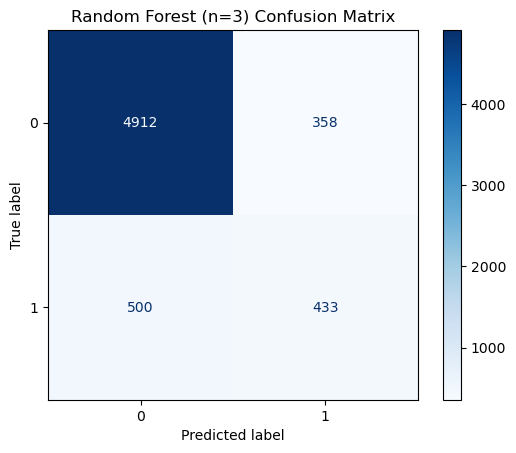

Recall (Yes): 0.4641
F1-score (Yes): 0.5023

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      5270
           1       0.55      0.46      0.50       933

    accuracy                           0.86      6203
   macro avg       0.73      0.70      0.71      6203
weighted avg       0.85      0.86      0.86      6203



In [344]:
from sklearn.metrics import confusion_matrix, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Training accuracy (on the oversampled train set)
train_acc = rf_clf.score(X_train_ros_2, y_train_ros_2)
print(f"Train Accuracy (oversampled): {train_acc:.4f}")

# 2) Test accuracy (on your original held-out test set)
test_acc = rf_clf.score(X_test_2, y_test_2)
print(f"Test  Accuracy:             {test_acc:.4f}")

# 3) Confusion matrix on the test set
y_pred = rf_clf.predict(X_test_2)
cm = confusion_matrix(y_test_2, y_pred, labels=rf_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rf_clf.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest (n=3) Confusion Matrix")
plt.show()

# 4) Recall & F1 for the positive class
recall = recall_score(y_test_2, y_pred, pos_label=rf_clf.classes_[1])
f1     = f1_score  (y_test_2, y_pred, pos_label=rf_clf.classes_[1])
print(f"Recall (Yes): {recall:.4f}")
print(f"F1-score (Yes): {f1:.4f}")

# 5) Full classification report
print("\n"+classification_report(y_test_2, y_pred))

In [314]:
y_train_2.value_counts()

y2
0    21213
1     3595
Name: count, dtype: int64